## XGBoost Model Analysis

### Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [2]:
# Load data from dataset_generators/datasets
final_df_with_lags = pd.read_csv('../dataset_generators/datasets/final_1_lag_ffa_dataset.csv')

In [3]:
# Function to load the KFold = 5 normalized data
def load_kfold_data(fold):
    train = pd.read_csv(f'../dataset_generators/datasets/{fold}_train_normalized.csv')
    test = pd.read_csv(f'../dataset_generators/datasets/{fold}_test_normalized.csv')
    return train, test

### XGBoost Analysis

In [4]:
# Load the model
with open('../model_generators/xgb/models/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

In [5]:
for fold in range(5):
    train, test = load_kfold_data(fold)
    X_train = train.iloc[:, 12:].drop(columns=['fantasy_points'])
    y_train = train['fantasy_points']
    X_test = test.iloc[:, 12:].drop(columns=['fantasy_points'])
    y_test = test['fantasy_points']
        
# Concatenate all test sets
all_test = pd.concat([load_kfold_data(fold)[1] for fold in range(5)], ignore_index=True)
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
all_test = all_test.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')
test = all_test
X_test = test.iloc[:, 12:].drop(columns=['fantasy_points'])
y_test = test['fantasy_points']

# Concatenate all train sets
all_train = pd.concat([load_kfold_data(fold)[0] for fold in range(5)], ignore_index=True)
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
all_train = all_train.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')
train = all_train
X_train = train.iloc[:, 12:].drop(columns=['fantasy_points'])
y_train = train['fantasy_points']

In [6]:
# # Use the trained model to plot MAE against various learning rates with area of std deviation as shaded region
# learning_rates = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
# def plot_mae_vs_learning_rate(X_train, y_train, X_test, y_test, learning_rates):
#     mae_values = []
#     for lr in learning_rates:
#         model = XGBRegressor(learning_rate=lr)
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         mae = mean_absolute_error(y_test, y_pred)
#         mae_values.append(mae)
#         mae_values_std = np.std(mae_values)
#         print(f"Learning Rate: {lr}, MAE: {mae}")

#     plt.figure(figsize=(10, 6))
#     plt.fill_between(learning_rates, np.array(mae_values) - mae_values_std, np.array(mae_values) + mae_values_std, alpha=0.2, color='r')
#     plt.plot(learning_rates, mae_values, color='r')
#     plt.xlabel('Learning Rate')
#     plt.ylabel('Mean Absolute Error (MAE)')
#     plt.title('MAE(w/ s.d.) vs Learning Rate, (max_depth=6)')
#     plt.grid(True)
#     plt.show()
    
# plot_mae_vs_learning_rate(X_train, y_train, X_test, y_test, learning_rates)

In [7]:
# # Use the trained model to plot MAE against various max_depth with area of std deviation as shaded region
# max_depths = [3, 4, 5, 6, 7, 8, 9, 10]
# def plot_mae_vs_max_depth(X_train, y_train, X_test, y_test, max_depths):
#     mae_values = []
#     for md in max_depths:
#         model = XGBRegressor(max_depth=md, learning_rate=0.01)
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         mae = mean_absolute_error(y_test, y_pred)
#         mae_values.append(mae)
#         mae_values_std = np.std(mae_values)
#         print(f"Max Depth: {md}, MAE: {mae}")

#     plt.figure(figsize=(10, 6))
#     plt.fill_between(max_depths, np.array(mae_values) - mae_values_std, np.array(mae_values) + mae_values_std, alpha=0.2, color='r')
#     plt.plot(max_depths, mae_values, color='r')
#     plt.xlabel('Max Depth')
#     plt.ylabel('Mean Absolute Error (MAE)')
#     plt.title('MAE(w/ s.d.) vs Max Depth, (learning_rate=0.01)')
#     plt.grid(True)
#     plt.show()

# plot_mae_vs_max_depth(X_train, y_train, X_test, y_test, max_depths)

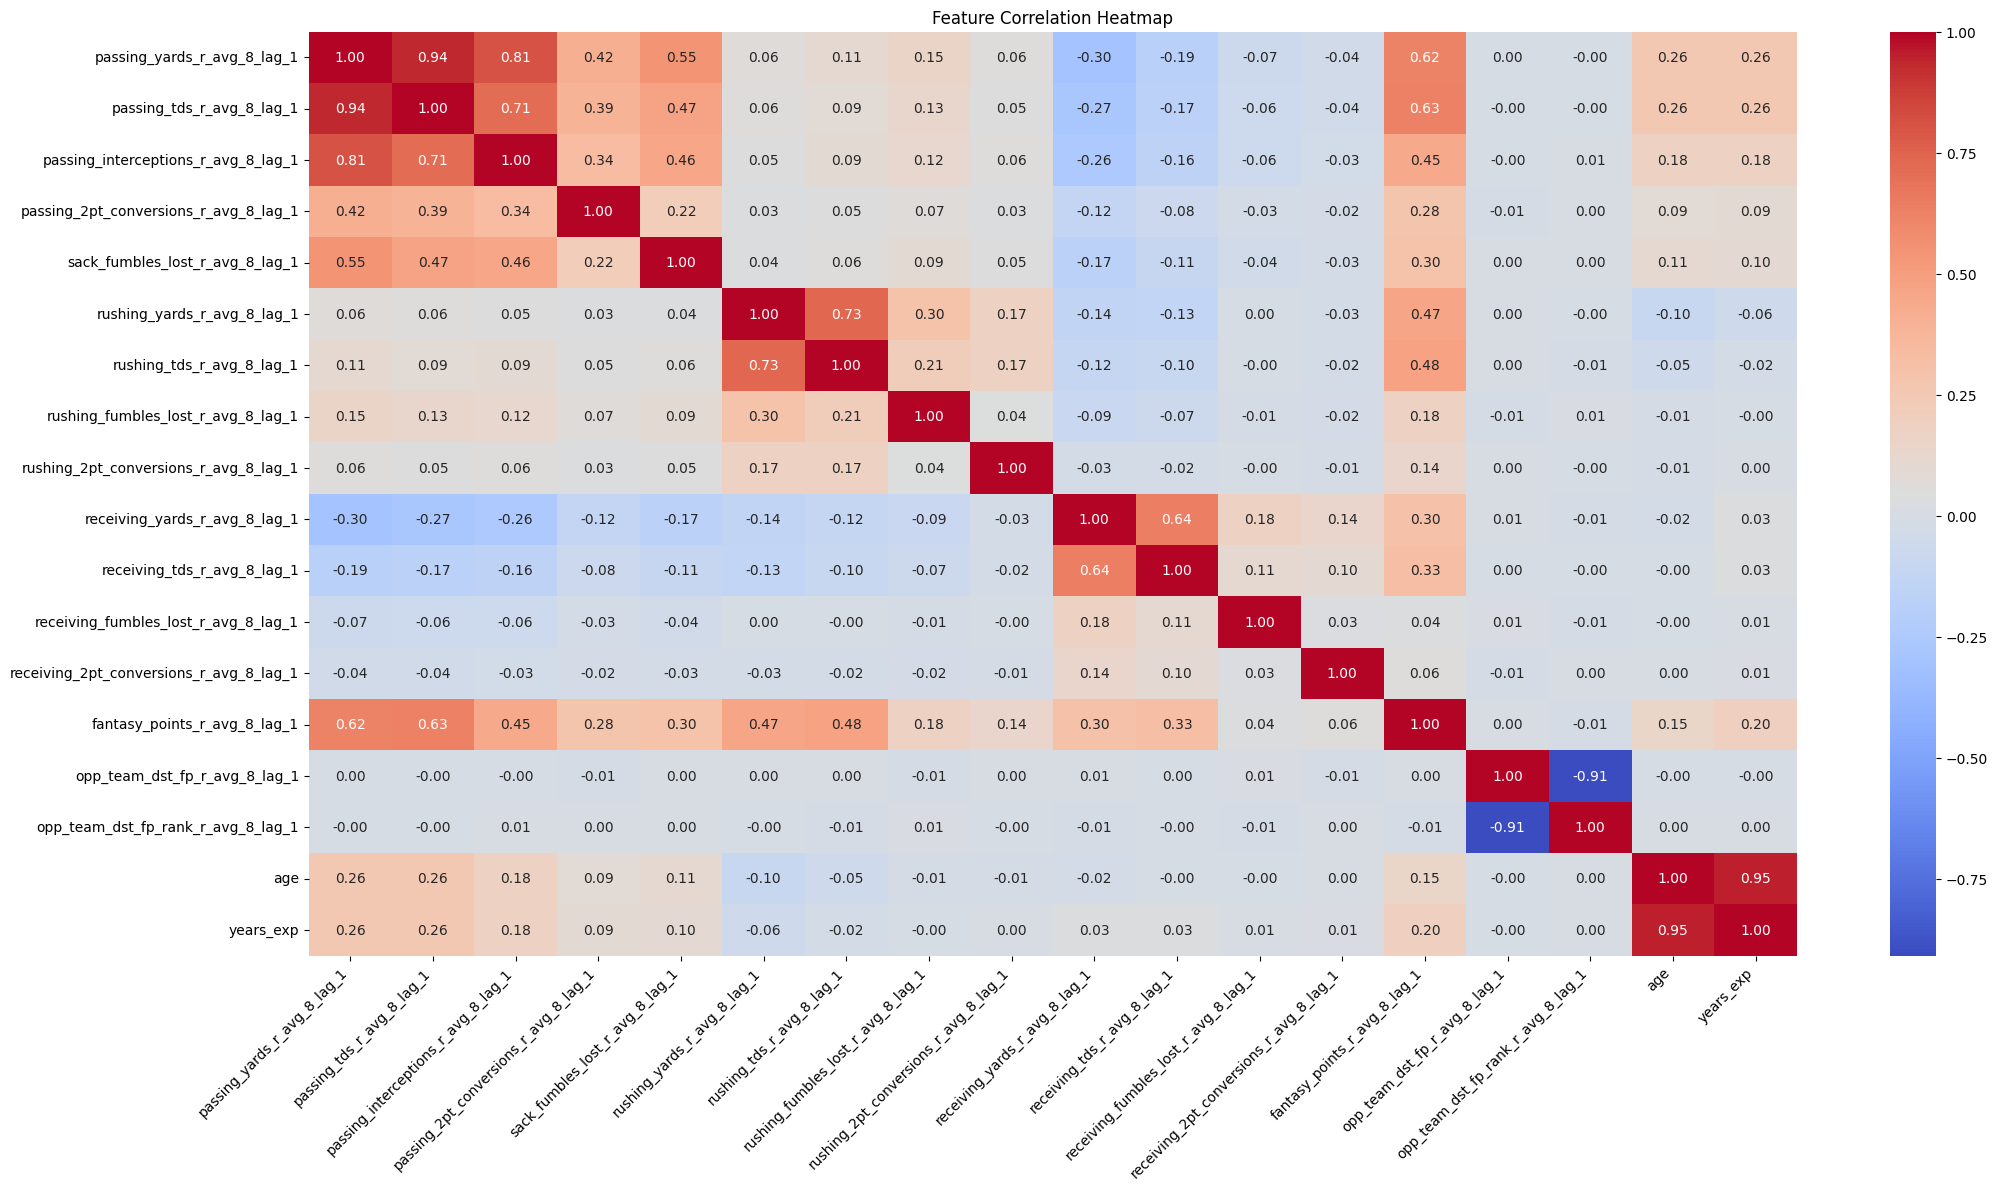

In [8]:
# Plot Correlation Heatmap
def plot_correlation_heatmap(feature_names):
    feature_names = feature_names.tolist() if isinstance(feature_names, pd.Index) else feature_names
    # Ensure only feature names that currently end with '_8_lag_1' except 'age' and 'years_exp'
    selected_features = [name for name in feature_names if name.endswith('_8_lag_1')] + ['age', 'years_exp']
    X_selected = X_train[selected_features]
    
    # Create a correlation matrix and plot the heatmap
    plt.figure(figsize=(24, 12))
    corr = X_selected.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.xticks(rotation=45, ha='right')
    plt.title("Feature Correlation Heatmap")
    plt.savefig('../model_visualizations/feature_correlation_heatmap.png')
    plt.show()
    plt.close()

plot_correlation_heatmap(X_train.columns)

In [9]:
# # Function to use SHAP to explain the machine learning model behavior with SHAP beeswarm plot

# def plot_shap_beeswarm(X_test, model):
#     explainer = shap.Explainer(model)
#     shap_values = explainer(X_test)
#     plt.figure(figsize=(10, 6))
#     shap.plots.beeswarm(shap_values)

# plot_shap_beeswarm(X_test, model)

In [10]:
# Function to use model to predict fantasy points for all weeks in final_df_with_lags, keeping 'player_id' for mapping back to player names later
def predict_fantasy_points(model):
    """
    Predict fantasy points for each player's next game using the trained model.
    
    Args:
        model: Trained XGBoost model
        final_df_with_lags: DataFrame containing player stats with lagged features
        
    Returns:
        numpy.array: Predicted fantasy points for each player
    """
    # Concatenate all test sets
    for fold in range(5):
        _, test = load_kfold_data(fold)
        if fold == 0:
            all_test = test
        else:
            all_test = pd.concat([all_test, test], ignore_index=True)
            
    test = all_test

    X_test = test.iloc[:, 12:].drop(columns=['fantasy_points'])

    # Make predictions
    predicted_fantasy_points = model.predict(X_test)

    test['predicted_fantasy_points'] = predicted_fantasy_points

    return test[['player_id', 'player_name', 'position_group', 'team', 'season', 'week', 'fantasy_points', 'predicted_fantasy_points']]

# Predict fantasy points for next week using the last trained model
predicted_fantasy_points = predict_fantasy_points(xgb_model)
predicted_fantasy_points

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,14.977148
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.519114
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,14.452259
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,11.346092
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,10.601549
...,...,...,...,...,...,...,...,...
60964,00-0039919,R.Odunze,WR,CHI,2024,6,4.00,5.793687
60965,00-0039919,R.Odunze,WR,CHI,2024,8,5.40,5.537357
60966,00-0039919,R.Odunze,WR,CHI,2024,13,2.50,5.784899
60967,00-0039919,R.Odunze,WR,CHI,2024,14,16.20,6.061800


In [11]:
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
predicted_fantasy_points = predicted_fantasy_points.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')

# Show the cleaned DataFrame
predicted_fantasy_points

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,14.977148
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.519114
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,14.452259
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,11.346092
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,10.601549
...,...,...,...,...,...,...,...,...
60964,00-0039919,R.Odunze,WR,CHI,2024,6,4.00,5.793687
60965,00-0039919,R.Odunze,WR,CHI,2024,8,5.40,5.537357
60966,00-0039919,R.Odunze,WR,CHI,2024,13,2.50,5.784899
60967,00-0039919,R.Odunze,WR,CHI,2024,14,16.20,6.061800


In [12]:
# Save the predictions to a CSV file
predicted_fantasy_points.to_csv('../predictions/xgb_predictions.csv', index=False)

In [13]:
# position_groups = predicted_fantasy_points['position_group'].unique()

# # Function for Prediction error analysis
# def analyze_prediction_errors(predicted_fantasy_points, position_group, season=2024):
#     predicted_fantasy_points = predicted_fantasy_points.copy()
#     # 2024 season only
#     predicted_fantasy_points = predicted_fantasy_points[predicted_fantasy_points['season'] == season]
#     # Filter by position_group
#     predicted_fantasy_points = predicted_fantasy_points[predicted_fantasy_points['position_group'] == position_group]
#     predicted_fantasy_points['prediction_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']

#     # Convert prediction_error to percent_error - not absolute
#     predicted_fantasy_points['percent_error'] = (predicted_fantasy_points['prediction_error'] / predicted_fantasy_points['fantasy_points'])

#     # Above and below zero errors
#     above_zero = predicted_fantasy_points[predicted_fantasy_points['prediction_error'] >= 0]
#     below_zero = predicted_fantasy_points[predicted_fantasy_points['prediction_error'] < 0]

#     plt.figure(figsize=(18, 6))

#     # Plot above 0 error chart with blue color and alpha 0.7
#     plt.bar(above_zero['player_name'], above_zero['prediction_error'], color='blue', alpha=0.7, label='Above Zero Error')
#     # Plot below 0 error chart with orange color and alpha 0.7
#     plt.bar(below_zero['player_name'], below_zero['prediction_error'], color='orange', alpha=0.7, label='Below Zero Error')
#     # All vertical grid lines throughout the plot
#     plt.grid(axis='x', linestyle='--', alpha=0.9)
#     # All horizontal grid lines throughout the plot
#     plt.grid(axis='y', linestyle='--', alpha=0.7)

#     # Remove X axis labels
#     plt.xticks([])

#     # plt.xlabel('Player Name')
#     plt.ylabel('Prediction Error')
#     plt.title(f'Prediction Error Analysis ({position_group} Test Set, 2024)')
#     # plt.xticks(rotation=90)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [14]:
# # Failure Analysis - show worst predictions by absolute value of prediction error for each position group regardless season (minimum of 5 fantasy points)
# def failure_analysis(predicted_fantasy_points, top_n=1):
#     predicted_fantasy_points = predicted_fantasy_points.copy()
#     # Filter for minimum fantasy points of 5
#     predicted_fantasy_points = predicted_fantasy_points[predicted_fantasy_points['fantasy_points'] >= 5]
#     predicted_fantasy_points['prediction_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']
#     predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['prediction_error'].abs()
    
#     # Group by position_group and get top N worst predictions for each group
#     worst_predictions = predicted_fantasy_points.groupby('position_group').apply(lambda x: x.nlargest(top_n, 'absolute_error')).reset_index(drop=True)
    
#     return worst_predictions[['player_id', 'player_name', 'position_group', 'team', 'season', 'week', 'fantasy_points', 'predicted_fantasy_points', 'absolute_error']]

# failure_analysis(predicted_fantasy_points, top_n=1)

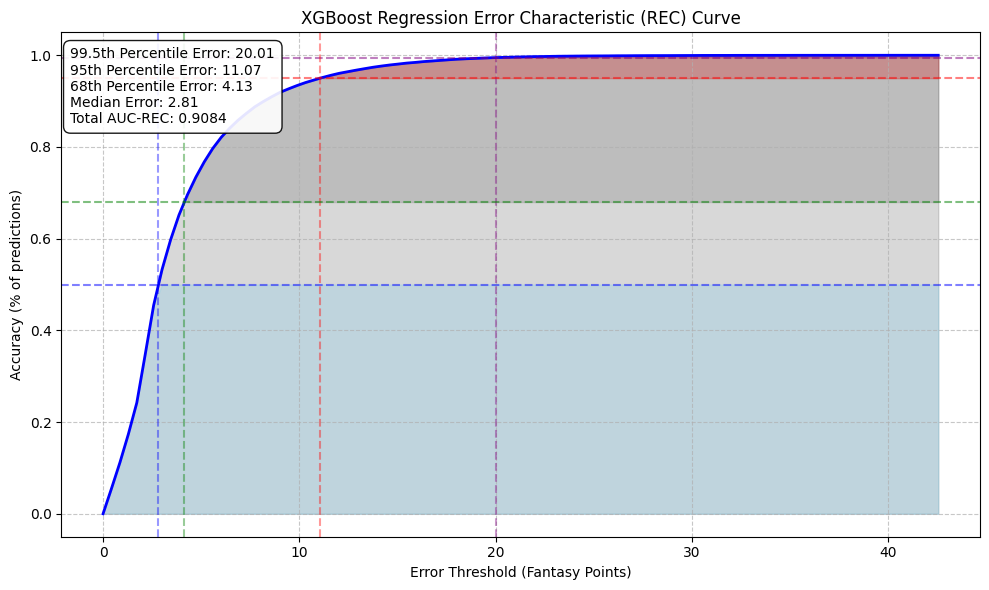

99.5th Percentile Error: 20.01 fantasy points
95th Percentile Error: 11.07 fantasy points
68th Percentile Error: 4.13 fantasy points
Median Error: 2.81 fantasy points
Total AUC-REC: 0.9084


In [15]:
# Function for Regression Error Characteristic (REC) Curves
def plot_rec_curve(predicted_fantasy_points):
    predicted_fantasy_points = predicted_fantasy_points.copy()
    
    # Calculate the absolute errors
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['absolute_error'].abs()
    
    # Calculate absolute errors
    errors = predicted_fantasy_points['absolute_error'].values
    
    # Create threshold values from 0 to max error
    thresholds = np.linspace(0, max(errors), 100)
    
    # Calculate accuracy for each threshold
    accuracies = [np.mean(errors <= threshold) for threshold in thresholds]
    
    # Plot REC curve
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, accuracies, 'b-', linewidth=2)
    plt.xlabel('Error Threshold (Fantasy Points)')
    plt.ylabel('Accuracy (% of predictions)')
    plt.title('XGBoost Regression Error Characteristic (REC) Curve')
    
    # Fill area under the curve
    plt.fill_between(thresholds, np.zeros_like(thresholds), accuracies, alpha=0.3, color='grey')
    
    # Fill 99.5th Percentile Error with different color
    percentile_99_5 = np.percentile(errors, 99.5)
    accuracy_99_5 = np.mean(errors <= percentile_99_5)
    plt.axvline(x=percentile_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Error: {percentile_99_5:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Accuracy: {accuracy_99_5:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 99.5th percentile (99.5% and above)
    plt.fill_between(thresholds, accuracy_99_5, accuracies, where=(thresholds >= percentile_99_5), color='purple', alpha=0.3, label='99.5% Accuracy Region')
    
    # Fill 95th Percentile Error with different color
    percentile_95 = np.percentile(errors, 95)
    accuracy_95 = np.mean(errors <= percentile_95)
    plt.axvline(x=percentile_95, color='red', linestyle='--', label=f'95th Percentile Error: {percentile_95:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_95, color='red', linestyle='--', label=f'95th Percentile Accuracy: {accuracy_95:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 95th percentile (95% and above)
    plt.fill_between(thresholds, accuracy_95, accuracies, where=(thresholds >= percentile_95), color='red', alpha=0.3, label='95% Accuracy Region')

    # Fill 68th Percentile Error with different color
    percentile_68 = np.percentile(errors, 68)
    accuracy_68 = np.mean(errors <= percentile_68)
    plt.axvline(x=percentile_68, color='green', linestyle='--', label=f'68th Percentile Error: {percentile_68:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_68, color='green', linestyle='--', label=f'68th Percentile Accuracy: {accuracy_68:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 68th percentile (68% and above)
    plt.fill_between(thresholds, accuracy_68, accuracies, where=(thresholds >= percentile_68), color='grey', alpha=0.3, label='68% Accuracy Region')

    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add reference line at median error
    median_error = np.median(errors)
    plt.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5)
    plt.axvline(x=median_error, color='blue', linestyle='--', label=f'Median Error: {median_error:.2f}', alpha=0.4)
    
    # Shaded region under the curve at median error (50% and below)
    plt.fill_between(thresholds, 0, np.minimum(accuracies, 0.5), color='skyblue', alpha=0.3, label='50% Accuracy Region')
    
    # Calculate total area under the REC curve (AUC-REC)
    auc_rec = np.trapz(accuracies, thresholds) / (max(thresholds) * 1)  # Normalize by max threshold

    # Add box to upper left corner with statistics
    stats_text = f'99.5th Percentile Error: {percentile_99_5:.2f}\n95th Percentile Error: {percentile_95:.2f}\n68th Percentile Error: {percentile_68:.2f}\nMedian Error: {median_error:.2f}\nTotal AUC-REC: {auc_rec:.4f}'
    plt.gca().text(0.01, 0.97, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))

    # Improve layout
    plt.tight_layout()
    # plt.savefig('rec_curve.png')
    plt.show()
    plt.close()
    
    # Print some statistics
    print(f"99.5th Percentile Error: {percentile_99_5:.2f} fantasy points")
    print(f"95th Percentile Error: {percentile_95:.2f} fantasy points")
    print(f"68th Percentile Error: {percentile_68:.2f} fantasy points")
    print(f"Median Error: {median_error:.2f} fantasy points")
    print(f"Total AUC-REC: {auc_rec:.4f}")
    
plot_rec_curve(predicted_fantasy_points)